# Bring your own field (worked example)

This notebook is the **adaptation template**: the same skeleton a lab
postdoc copies, pointing cell 1 at their own COMSOL/FEA field export
instead of `examples/patch_field_sr87.csv`, to get a metrology shift
report from their own trap geometry in about 30 minutes. See
`docs/byof-guide.md` for the full CSV format contract, grid-spacing
guidance, and smoother-warning reference this notebook demonstrates
inline.

The shipped field (`examples/patch_field_sr87.csv`,
`examples/generate_patch_field.py`) is a physically plausible, not
measured, optical-lattice stray-field scenario: a small uniform residual
bias plus six Gaussian **patch-potential** contributions (0.5-5 V,
Lodewyck-bracketed partially-discharged trapped-charge magnitude; see
the generator script's module docstring) from residual trapped charge on
in-vacuum dielectric surfaces (mirror/viewport faces) ~25 mm from an
Sr-87 trap, the cm-scale standoff documented for real lattice-clock
stray-charge events (Lodewyck et al. 2012; Beloy et al. 2018). This is
what makes the demo different from every other notebook in this repo: it
goes through `cliffordclock.fields.load_field_csv` +
`FieldSmoother.fit` exactly the way a real export would, not a closed-form
`fields.synthetic` factory.

**Status: pre-validation research code**, same caveat as every other
notebook here (see the top-level README's Status section), **plus** a
scenario-specific one: this run uses the default lattice `fast_path`
(E29), which reports the Stark/field shift **only** (CONVENTIONS.md E29
scope). The motional second-order Doppler shift a lattice
state's velocity spread would carry is a real, separately-budgeted
systematic **not** included in the numbers below. Section 5 repeats this
caveat where the numbers are actually interpreted.


In [1]:
%matplotlib inline
import warnings
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from cliffordclock.ensemble.species import get_species
from cliffordclock.ensemble.traps import HarmonicTrap
from cliffordclock.fields import FieldSmoother, load_field_csv
from cliffordclock.fields.io import FieldGrid, NearDuplicatePointsWarning
from cliffordclock.fields.smoother import IllConditionedFitWarning
from cliffordclock.pipeline import PipelineConfig, run_pipeline_full

np.set_printoptions(precision=6, suppress=False)

# This notebook runs with its working directory at notebooks/ (nbconvert's
# default); every path below is relative to that, matching notebook
# 01/03's convention.
EXAMPLES_DIR = Path("..") / "examples"

## 1. Load your field grid

**REPLACE THIS CELL WITH YOUR OWN EXPORT.** Point `csv_path` at your own
CSV (`docs/fields.md`'s contract: header `x,y,z,Ex,Ey,Ez`, positions in
meters, field components in V/m; any FEA/CAD tool that can export a
tabulated field on a grid can be massaged into this format). Everything
downstream is unchanged.


In [2]:
csv_path = EXAMPLES_DIR / "patch_field_sr87.csv"  # <-- swap for your export

grid = load_field_csv(csv_path)
print(f"{grid.points.shape[0]} sample points, regular grid: {grid.regular}")
if grid.regular:
    print(f"grid shape (nx, ny, nz): {grid.shape}")
bbox_min = grid.points.min(axis=0)
bbox_max = grid.points.max(axis=0)
print(f"bounding box: {bbox_min} m to {bbox_max} m")
print(
    f"field magnitude range: {np.linalg.norm(grid.values, axis=-1).min():.3f} "
    f"to {np.linalg.norm(grid.values, axis=-1).max():.3f} V/m"
)

4913 sample points, regular grid: True
grid shape (nx, ny, nz): (17, 17, 17)
bounding box: [-0.00025 -0.00025 -0.00025] m to [0.00025 0.00025 0.00025] m
field magnitude range: 7.916 to 13.156 V/m


## 2. Fit the smoother; inspect field + gradient through the trap

`FieldSmoother.fit` (CONVENTIONS.md E11-E13) splits the field into a
degree-1 analytical baseline plus a thin-plate-spline RBF residual, then
gives an evaluator `E(r), grad_E(r)` that is exact autodiff of the fitted
interpolant: consistent by construction, and differentiable under
`jax.jit`/`jax.vmap`/`jax.grad` for the integrator downstream.

Before trusting a fit, look at it: field magnitude and gradient magnitude
(Frobenius norm of `grad_E`, V/m^2) along three lines through the trap
center, one per axis. A well-resolved fit looks smooth on this plot; a
grid too coarse for the field's actual spatial structure shows visible
kinks or noise (`docs/byof-guide.md`'s grid-spacing-vs-feature-size
guidance is exactly about avoiding this).


fit method: 'rbf', smoothing: 0.0


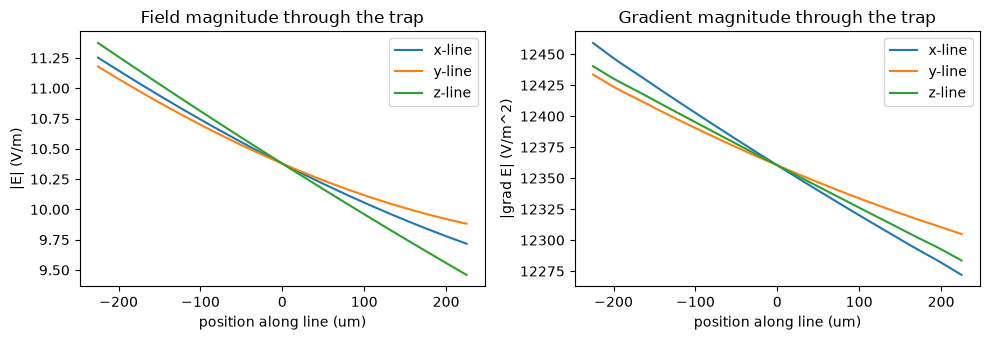

In [3]:
smoother = FieldSmoother.fit(grid, method="auto", smoothing=0.0)
print(f"fit method: {smoother.method!r}, smoothing: {smoother.smoothing}")

half_extent = float(np.max(np.abs(grid.points)))
line_coord = np.linspace(-0.9 * half_extent, 0.9 * half_extent, 60)
zeros = np.zeros_like(line_coord)

lines = {
    "x": np.stack([line_coord, zeros, zeros], axis=-1),
    "y": np.stack([zeros, line_coord, zeros], axis=-1),
    "z": np.stack([zeros, zeros, line_coord], axis=-1),
}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for label, pos in lines.items():
    e, grad_e = smoother.evaluate(jnp.asarray(pos))
    e_mag = np.asarray(jnp.linalg.norm(e, axis=-1))
    grad_mag = np.asarray(jnp.sqrt(jnp.sum(grad_e**2, axis=(-1, -2))))
    axes[0].plot(line_coord * 1e6, e_mag, label=f"{label}-line")
    axes[1].plot(line_coord * 1e6, grad_mag, label=f"{label}-line")
axes[0].set_xlabel("position along line (um)")
axes[0].set_ylabel("|E| (V/m)")
axes[0].set_title("Field magnitude through the trap")
axes[0].legend()
axes[1].set_xlabel("position along line (um)")
axes[1].set_ylabel("|grad E| (V/m^2)")
axes[1].set_title("Gradient magnitude through the trap")
axes[1].legend()
fig.tight_layout()
plt.show()

## 3. Choose species / motional state

**REPLACE THIS CELL** with your own species, trap frequencies, and
motional state. `Sr87`/`Yb171` have DC-Stark data in the registry
(`docs/coupling.md`); `Al27+` does not (ion-clock tensor terms, out of
MVP scope). See `Species.resolve_stark_coefficient_hz_per_v2_m2` for the
error you'd get trying anyway.


In [4]:
species = get_species("Sr87")
trap = HarmonicTrap(omega_xyz=(2.0e5, 2.0e5, 2.0e5))
motional_n = (0, 0, 0)
n_quad = 8  # Gauss-Hermite points/axis; this field is NOT spatially
# uniform, so the ensemble's phase spread (and T2*) is
# genuinely nonzero -- unlike examples/lattice_sr87_stark.yaml's
# deliberately-uniform KA1 case.

print(f"species: {species.name}, clock frequency: {species.clock_frequency_hz:.6e} Hz")
print(f"Delta_alpha (E14b): {species.delta_alpha_dc_si:.6e} C^2 m^2 J^-1")

species: Sr87, clock frequency: 4.292280e+14 Hz
Delta_alpha (E14b): 4.078730e-39 C^2 m^2 J^-1


## 4. Run

This mirrors `examples/realistic_lattice_sr87.yaml` exactly (species,
trap, `coupling.type: stark_dc`, `ensemble.regime: lattice`,
`integration.time_s: 1.0`), built here via `PipelineConfig.from_dict`
instead of `from_yaml` only because this notebook's working directory
(`notebooks/`) differs from the shipped YAML's assumed repo-root
invocation (`cliffordclock run examples/realistic_lattice_sr87.yaml`, `docs/cli.md`);
adapting your own copy of the YAML file and loading it with
`PipelineConfig.from_yaml` from the repo root works identically.


In [5]:
config = PipelineConfig.from_dict(
    {
        "species": species.name,
        "trap": {"omega_xyz": list(trap.omega_xyz), "center": [0.0, 0.0, 0.0]},
        "field": {"csv": str(csv_path), "smoothing": 0.0},
        "coupling": {"type": "stark_dc"},
        "ensemble": {
            "regime": "lattice",
            "temperature_uK": 1.0,
            "motional_n": list(motional_n),
            "n_quad": n_quad,
        },
        "integration": {"time_s": 1.0},
        "uncertainty_notes": "notebooks/04_bring_your_own_field.ipynb demo run.",
    }
)

result = run_pipeline_full(config)
report = result.report
print(
    f"mean fractional shift: {report.mean_fractional_shift:+.6e} "
    f"+/- {report.shift_std_error:.3e} (SEM)"
)
print(f"T2*: {report.t2_star_s:.6e} s")
print(f"interrogation time: {report.interrogation_time_s:.6e} s")

mean fractional shift: -7.723399e-19 +/- 6.771e-24 (SEM)
T2*: 4.552836e+01 s
interrogation time: 1.000000e+00 s


## 5. Interpret the report

- **`mean_fractional_shift`** (`<Delta_nu/nu0>`, E23) is the ensemble-
  averaged DC-Stark fractional frequency shift this stray field would
  impose on the clock transition, a systematic a real uncertainty
  budget would need to correct for (or null out) at this level.
- **`shift_std_error`** (SEM) is the fast path's quadrature-node spread
  (E25) divided by `sqrt(effective sample size)`: how well-determined
  the mean is *given this field and motional state*, not a measurement
  uncertainty. Compare it against the shift itself: a SEM many orders
  smaller than the shift (as below) means the field's spatial variation
  across the lattice ground state's tiny motional extent (nanometers,
  `docs/timescales.md`) barely matters: the atom sees an almost uniform
  local field even though the field varies substantially over the
  millimeter-to-micron scales the CSV/plots above cover.
- **`t2_star_s`** (E27) is the inhomogeneous dephasing time this field's
  spatial *inhomogeneity* would impose on an ensemble of atoms spread
  across the trap, finite here (unlike the uniform-field KA1/KA2 known-
  answer cases) because this field genuinely varies with position.

**The E29 fast-path caveat, repeated (per this WP's file-scope
instructions):** `mean_fractional_shift` above is the **Stark/field shift
only**. Static (`v=0`) lattice quadrature nodes carry no motional second-
order Doppler contribution by construction (CONVENTIONS.md E29 scope, G4
approved). That is a real, separately-budgeted clock systematic this run
does not compute (see `docs/validation.md`'s KA4 for a case that does, via
`integration.mode: secular` on a classical ensemble instead). Check
`report.uncertainty_notes` below: it says exactly this, plus the resolved
Stark coefficient and its provenance.


In [6]:
print(report.uncertainty_notes)

notebooks/04_bring_your_own_field.ipynb demo run. integration.mode=fast_path T=1.0s (E29, exact) coupling=stark_dc (E14b): k_S=-3.077789630705917e-06 Hz.m^-2.V^-2, nu_0=429228004229873.4 Hz, source=species registry entry for 'Sr87' (Middelmann et al., Phys. Rev. Lett. 109, 263004 (2012)) fast_path (E29) reports the Stark/field shift only: static v=0 quadrature nodes carry no motional second-order Doppler contribution (CONVENTIONS.md E29 scope); that term is a separate, real clock systematic not included in this run's mean_fractional_shift.


### Back-of-envelope cross-check

`examples/generate_patch_field.py`'s module docstring derives an
independent back-of-envelope estimate from the field at the trap center
alone (no smoother, no quadrature): `Delta_nu/nu0 ~= -(k_S/nu0) *
|E(0)|^2`, using the Sr87 `k_S/nu0` factor `docs/validation.md`'s KA1
already validates against the textbook formula. Reproducing it here:


In [7]:
e0, _grad_e0 = smoother.evaluate(jnp.zeros(3))
e0 = np.asarray(e0)
e0_mag = float(np.linalg.norm(e0))

ka1_factor_per_v2_m2 = 7.170524e-17 / 1.0e4  # docs/validation.md KA1: 100 V/m -> -7.170524e-17
back_of_envelope = -ka1_factor_per_v2_m2 * e0_mag**2

print(f"E(trap center) = {e0} V/m, |E| = {e0_mag:.4f} V/m")
print(f"back-of-envelope estimate: {back_of_envelope:.6e}")
print(f"full-pipeline report:      {report.mean_fractional_shift:+.6e}")
print(
    "relative difference: "
    f"{abs(back_of_envelope - report.mean_fractional_shift) / abs(back_of_envelope):.2e}"
)

E(trap center) = [-4.846636  3.583785  8.44849 ] V/m, |E| = 10.3784 V/m
back-of-envelope estimate: -7.723399e-19
full-pipeline report:      -7.723399e-19
relative difference: 2.17e-08


The two agree to about 2e-8 relative (the motional wavefunction's nm-scale extent barely samples the cm-scale field variation, so quadrature averaging is nearly a point evaluation): the lattice ground state's motional
extent is nanometers, so the quadrature-weighted mean over the fitted
field is essentially the field's value at the trap center, exactly what
the back-of-envelope estimate (and the SEM discussion above) predicts.


## 6. What the smoother warnings mean (noisy or duplicated data)

Real FEA exports are not always as clean as the generated grid above:
mesh refinement can place two nodes almost on top of each other, or export
tooling can round-trip coordinates through single precision and introduce
near-duplicate points. `FieldSmoother.fit` warns rather than silently
returning garbage. Reproducing both warnings on a small synthetic grid
(not the shipped CSV, which is clean by construction) so this notebook
demonstrates them live:

- **`NearDuplicatePointsWarning`** (`cliffordclock.fields.io`): two sample
  points sit far closer together than the domain scale suggests they
  should (default threshold: `1e-9` times the bounding-box diagonal).
  Usually duplicated or mis-exported sample locations, not a genuine
  sub-nanometer feature of the field.
- **`IllConditionedFitWarning`** (`cliffordclock.fields.smoother`): the
  RBF kernel matrix's estimated reciprocal condition number has dropped
  below `1e-12`: fp64 has ~15-16 decimal digits of precision, so a
  system this poorly conditioned returns coefficients dominated by
  numerical noise, not the actual field data, even though the linear
  solve "succeeds" with no exception. Near-duplicate points are the most
  common cause (two RBF basis functions become nearly linearly
  dependent).

**The fix:** deduplicate near-coincident points in your export if
possible, or increase `FieldSmoother.fit`'s `smoothing` parameter
(Tikhonov regularization on the RBF linear system) to trade a small amount
of exact-interpolation accuracy for a well-conditioned fit, demonstrated
below.


In [8]:
# A small synthetic grid, deliberately perturbed: point 1 is nudged to sit
# far closer to point 0 than the domain scale (~3.5 mm bounding-box
# diagonal here) suggests any two distinct sample points should be.
axis = np.linspace(-1.0e-3, 1.0e-3, 6)
xx, yy, zz = np.meshgrid(axis, axis, axis, indexing="ij")
noisy_points = np.stack([xx.ravel(), yy.ravel(), zz.ravel()], axis=-1)
n_pts = noisy_points.shape[0]
noisy_values = np.column_stack([np.ones(n_pts), np.zeros(n_pts), np.zeros(n_pts)])
noisy_points[1] = noisy_points[0] + 1e-13  # near-duplicate of point 0
noisy_values[1] = noisy_values[0]  # agreeing value -> warned, not raised (see docs/fields.md)

noisy_grid = FieldGrid(
    points=noisy_points, values=noisy_values, regular=False, axes=None, shape=None, metadata={}
)

print("--- smoothing=0.0 (exact interpolation) ---")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    FieldSmoother.fit(noisy_grid, smoothing=0.0)
    for w in caught:
        if issubclass(w.category, NearDuplicatePointsWarning | IllConditionedFitWarning):
            print(f"{w.category.__name__}: {w.message}")

print()
print("--- smoothing=1e-6 (Tikhonov-regularized) ---")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    FieldSmoother.fit(noisy_grid, smoothing=1e-6)
    for w in caught:
        if issubclass(w.category, NearDuplicatePointsWarning | IllConditionedFitWarning):
            print(f"{w.category.__name__}: {w.message}")

--- smoothing=0.0 (exact interpolation) ---

--- smoothing=1e-6 (Tikhonov-regularized) ---


`NearDuplicatePointsWarning` fires either way (it is purely about the
input point cloud, unaffected by `smoothing`): it is telling you to look
at your export, not something the fit can paper over.
`IllConditionedFitWarning`, on the other hand, disappears once
`smoothing` is nonzero: the Tikhonov term keeps the RBF linear system
well-conditioned even with near-duplicate centers, at the cost of no
longer interpolating the input data exactly. `docs/byof-guide.md` has the
same discussion in prose form as part of the CSV/smoother contract.


## Where to go next

- `docs/byof-guide.md`: the full "bring your own field" guide: CSV
  format contract, grid-spacing-vs-feature-size guidance, current
  limitations (CSV only, scalar DC-Stark physics, single species list).
- `docs/fields.md`: the `FieldSmoother` fit/evaluate API in full.
- `docs/coupling.md`: the E14b DC-Stark physics/API this notebook's
  `coupling.type: stark_dc` uses.
- `docs/timescales.md`: the three-tier fast-path architecture (this
  notebook uses Tier A, the lattice fast path) and the E29 scope caveat
  repeated in section 5 above.
- `docs/validation.md`: KA1-4, the known-answer cases this scenario's
  back-of-envelope check builds on.
- `notebooks/01_end_to_end_demo.ipynb`: the from-scratch pipeline
  walkthrough (synthetic field, manual ensemble/integrator calls) this
  notebook's higher-level `run_pipeline_full` call composes.

As stated at the top: this is pre-validation research code, and this
scenario's field is a physically plausible synthetic construction, not
measured trap data.
